# 7. Final Model Evaluation, Insights & Saving


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, roc_curve
import joblib, os, json


In [2]:
# Load the cleaned and preprocessed data
df = pd.read_csv('../data/processed_data.csv')

X = df.drop('Churn', axis=1)
y = df['Churn']

# Recreate the same train/test split used in modeling
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
# Load the fitted scaler and apply it to both sets
scaler = joblib.load('../models/scaler.pkl')
cols_to_scale = ['tenure', 'MonthlyCharges', 'TotalCharges']
X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_train[cols_to_scale] = scaler.transform(X_train[cols_to_scale])


In [4]:
# Load the tuned final model
best_xgb = joblib.load('../models/best_xgb.pkl')

# Generate predictions
y_pred_xgb_tuned = best_xgb.predict(X_test)
y_proba_xgb_tuned = best_xgb.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred_xgb_tuned))
print("ROC-AUC:", roc_auc_score(y_test, y_proba_xgb_tuned))


              precision    recall  f1-score   support

           0       0.93      0.72      0.81      1036
           1       0.52      0.85      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.78      0.73      1409
weighted avg       0.82      0.75      0.77      1409

ROC-AUC: 0.8624349167244609


In [5]:
# Confusion Matrix for the final tuned XGBoost model
cm_final = confusion_matrix(y_test, y_pred_xgb_tuned)
print(cm_final)


[[743 293]
 [ 56 317]]


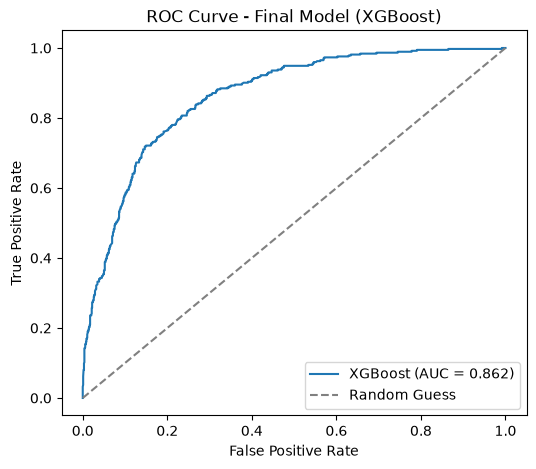

In [6]:
# Plot ROC curve for the final model
fpr, tpr, thresholds = roc_curve(y_test, y_proba_xgb_tuned)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f'XGBoost (AUC = {roc_auc_score(y_test, y_proba_xgb_tuned):.3f})')
plt.plot([0,1], [0,1], linestyle='--', color='gray', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Final Model (XGBoost)')
plt.legend()
plt.show()


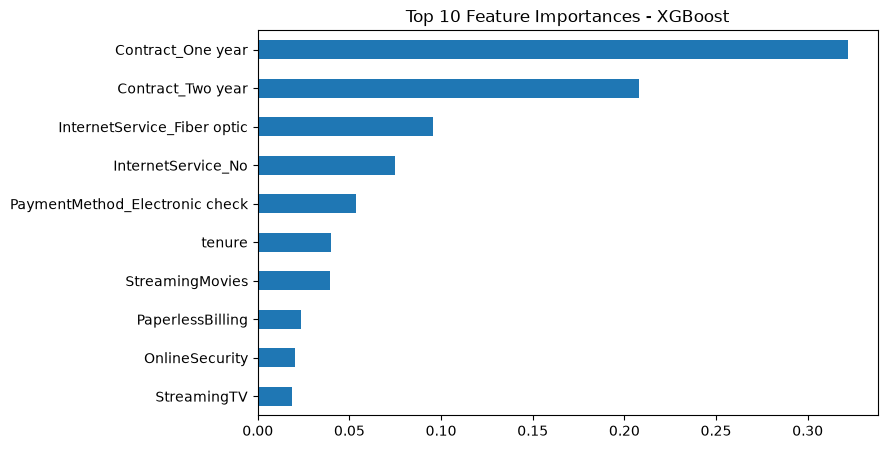

In [7]:
# Feature Importance for the final XGBoost model
importances_xgb = pd.Series(best_xgb.feature_importances_, index=X_train.columns)
importances_xgb = importances_xgb.sort_values(ascending=False)

plt.figure(figsize=(8,5))
importances_xgb.head(10).plot(kind='barh')
plt.title('Top 10 Feature Importances - XGBoost')
plt.gca().invert_yaxis()
plt.show()


##  Business Insights & Recommendations

**Final model:** XGBoost (Tuned) — selected for the highest Recall (0.85)
and ROC-AUC (0.862) among all models tested, meaning it catches the most
at-risk customers while maintaining strong overall discriminative power.

**Key churn drivers** (confirmed by both EDA and XGBoost Feature Importance):
- Month-to-month contracts have a much higher churn rate than 1-2 year contracts
- Fiber optic internet customers churn more than DSL customers
- Electronic check payment is associated with the highest churn rate among payment methods
- New customers (low tenure) are more likely to churn
- Higher monthly/total charges are associated with increased churn risk

**Highest-risk customer segment:**
New customer, month-to-month contract, Fiber optic internet, paying via
Electronic check, with a high monthly charge.

**Business recommendations:**
1. Incentivize customers to switch from month-to-month contracts to 1-2 year contracts (e.g. discounts, loyalty offers)
2. Investigate and improve Fiber optic service quality and support
3. Encourage automatic payment methods over Electronic check
4. Provide extra onboarding/support attention to new customers in their first 3-6 months
5. Prioritize retention outreach based on the model's churn probability score, focusing resources on the highest-risk segment above


## Saving the Model

In [8]:


import joblib

# Save the tuned XGBoost model as the final model
joblib.dump(best_xgb, '../models/churn_model.pkl')
joblib.dump(scaler, '../models/scaler.pkl')
feature_names = list(X_train.columns)
with open('../models/feature_names.json', 'w') as f:
    json.dump(feature_names, f)

preprocessing_config = {
    'scale_cols': ['tenure', 'MonthlyCharges', 'TotalCharges']
}
with open('../models/preprocessing_config.json', 'w') as f:
    json.dump(preprocessing_config, f)
